In [2]:
import numpy
import itertools
import math
import gsd.hoomd
import os
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display


#Grabbing helper scripts
import md_Helpers.Create_Lattices as cl
import md_Helpers.Simulation_Helpers as sh
import md_Helpers.Logging_Helpers as lh
import md_Helpers.viz_helpers as vh
from md_Helpers.Project_Paths import THERMALIZED_STATES_ROOT


import importlib
importlib.reload(cl)
importlib.reload(sh)
importlib.reload(lh)
importlib.reload(vh)

<module 'md_Helpers.viz_helpers' from '/home/pnichols/MDsims/md_Helpers/viz_helpers.py'>

In [12]:
result = sh.get_or_make_thermalized_state(
    BoxLength=50.0,
    target_rho=0.8,
    kT=0.80,
    nsteps=5_000_000,
    overwrite=False,
)

paths = result["paths"]

Loaded existing lattice:
/exp/e961/data/MDsims-data/pnichols/Simple_Lattices/FCC/BoxLength_50.0/rho_0.80/lattice.gsd
Using GPU device
Final device: <hoomd.device.GPU object at 0x7f8cd35f0830>
Started HDF5 logger
Log file: /exp/e961/data/MDsims-data/pnichols/Thermalized_States/BoxLength_50.0/rho_0.80/kT_0.80/randomization_nsteps_5000000_log.hdf5
Stopped HDF5 logger
Wrote HDF5 metadata
Saved final state
GSD file: /exp/e961/data/MDsims-data/pnichols/Thermalized_States/BoxLength_50.0/rho_0.80/kT_0.80/randomization_nsteps_5000000.gsd


In [13]:
print(result.keys())
print(result['created_new'])

dict_keys(['frame', 'simulation', 'paths', 'created_new'])
True


In [14]:
log_data = lh.read_hdf5_log(paths["log_path"])
log_data["metadata"]['attrs']

{'Lx': 50.0,
 'Ly': 50.0,
 'Lz': 50.0,
 'N': 97556,
 'actual_rho': 0.780448,
 'dt': 0.005,
 'epsilon_LJ': 1.0,
 'final_timestep': 5000000,
 'kT': 0.8,
 'lj_mode': 'xplor',
 'log_period': 1000,
 'nsteps': 5000000,
 'phase_name': 'randomization',
 'phase_separated': False,
 'r_cut_LJ': 2.5,
 'r_on_LJ': 2.0,
 'seed': 1,
 'sigma_LJ': 1.0,
 'starting_state_path': '/exp/e961/data/MDsims-data/pnichols/Simple_Lattices/FCC/BoxLength_50.0/rho_0.80/lattice.gsd',
 'target_rho': 0.8,
 'volume': 125000.0}

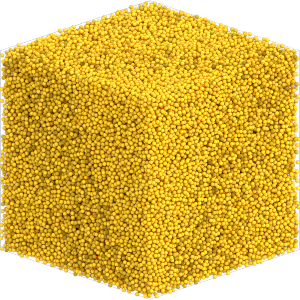

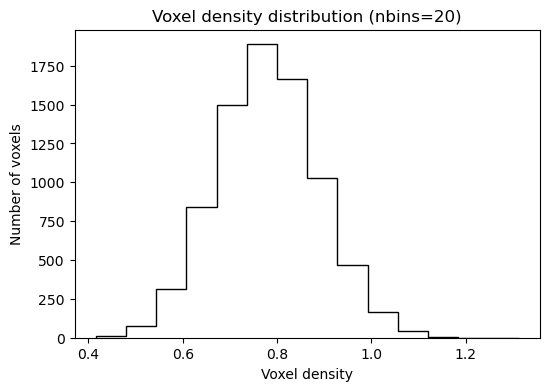

In [15]:
sim = result["simulation"]

display(vh.render(sim.state.get_snapshot()))

vh.plot_voxel_histogram(sim, nbins=20);

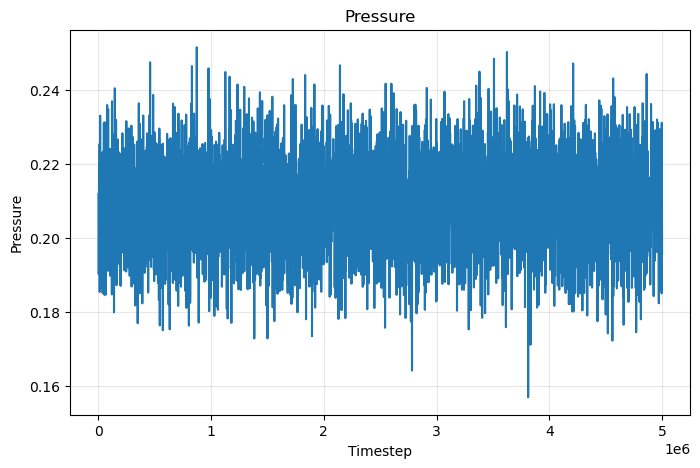

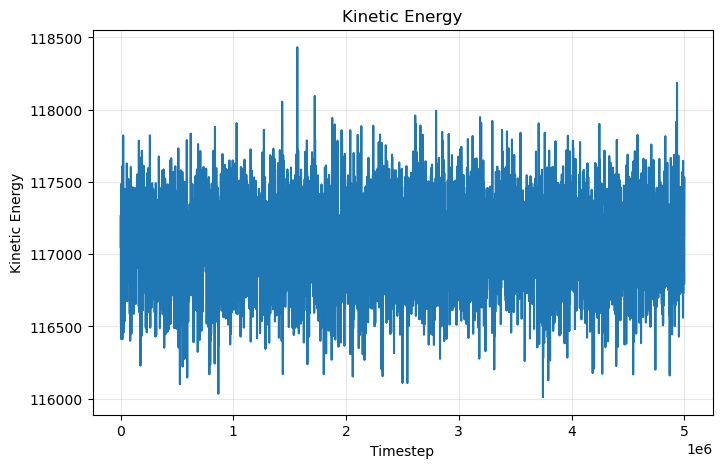

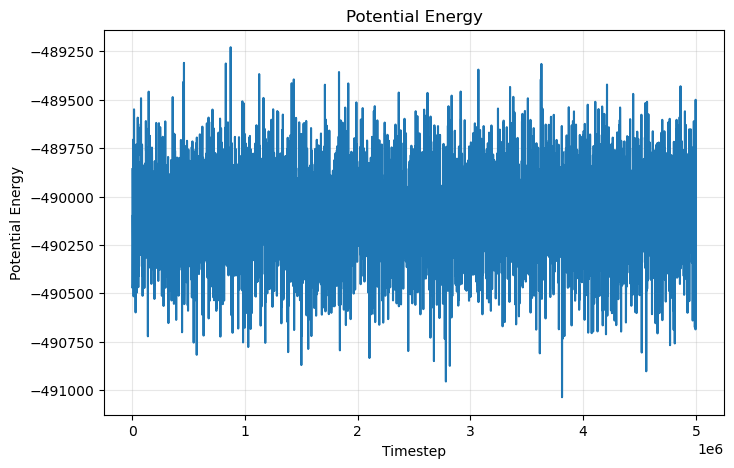

In [16]:
vh.plot_log_quantity(log_data, "pressure")
vh.plot_log_quantity(log_data, "kinetic_energy")
vh.plot_log_quantity(log_data, "potential_energy")

In [ ]:
vh.plot_xy_particles(sim)

In [ ]:
vh.plot_xy_slice(sim, fraction=0.025)